In [14]:
import pandas as pd
import os
from pathlib import Path

In [ ]:
def load_data(path: str) -> pd.DataFrame:
    """loads data from a csv file and returns a pandas DataFrame"""
    df = pd.read_csv(path)
    return df


def load_customers() -> pd.DataFrame:
    """loads customer data from the subject folder and returns a pandas DataFrame"""
    dfs = []
    base_path = Path.cwd()
    data_path = (base_path / "../subject/customer").resolve()

    if not data_path.exists():
        print(f"Directory not found: {data_path}")
        return

    for file in data_path.glob("*.csv"):
        dfs.append(pd.read_csv(file))
        
    contacts = pd.concat(dfs)
    contacts['event_time'] = pd.to_datetime(contacts['event_time'])
    return contacts


def load_items():
    """loads item data from the subject folder and returns a pandas DataFrame"""
    df = load_data("../subject/item/item.csv")
    return df


def merge_data(items, customers) -> pd.DataFrame:
    """merges the customer and item dataframes on the product_id column and returns a new DataFrame"""
    df = pd.merge(customers, items, on="product_id")
    return df


def remove_doubles(df: pd.DataFrame) -> pd.DataFrame:
    """
    removes rows from the DataFrame where the same 
    product_id, event_type, and event_time occur 
    within 1 second of each other
    """
    df = df.sort_values(by=['product_id', 'event_type', 'event_time'])
    time_diff = df.groupby(['product_id', 'event_type'])['event_time'].diff()
    df_cleaned = df[~(time_diff <= pd.Timedelta(seconds=1))]
    return df_cleaned

In [22]:
customers = load_customers()
customers = remove_doubles(customers)
items = load_items()
customers = merge_data(items, customers)

In [23]:
customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36857483 entries, 0 to 36857482
Data columns (total 9 columns):
 #   Column         Dtype              
---  ------         -----              
 0   event_time     datetime64[ns, UTC]
 1   event_type     object             
 2   product_id     int64              
 3   price          float64            
 4   user_id        int64              
 5   user_session   object             
 6   category_id    float64            
 7   category_code  object             
 8   brand          object             
dtypes: datetime64[ns, UTC](1), float64(2), int64(2), object(4)
memory usage: 2.5+ GB


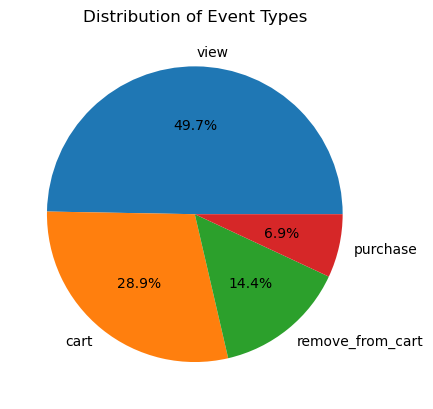

In [ ]:
import matplotlib.pyplot as plt
data = customers["event_type"]
data.value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("Distribution of Event Types")
plt.ylabel("")
plt.show()